### PSD Noise

We plot the noise due to PSD in this notebook. Initially, we ran into the problem of scaling: PSD and Noise-PSD looked similar, but they didn't lie on top of each other. This was resolved by choosing the correct scaling factor

In [1]:
import os as os
import sys

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

import matplotlib.pyplot as plt
from scripts.wosa import wosa
from scripts.psdAndPlot import psd_and_plot_hor
from scripts.psdAndPlotTDI import psdAndPlotTDI
from scripts.readTdi import readTdi
from scripts.psdNoise import time_noise_from_psd
import numpy as np
import scipy.signal 

In [2]:
bethLISA_directory = os.path.join(os.getcwd(), "..", "..", "bethLISA")
tdi_output_directory = os.path.join(bethLISA_directory, 'lisa_glitch_simulation', 'tdi_outputs')
tdi_file_name = "small_glitch_tdi.h5"
tdi_file_path = os.path.join(tdi_output_directory, tdi_file_name)

Text(0.5, 1.0, 'WOSA, log scale')

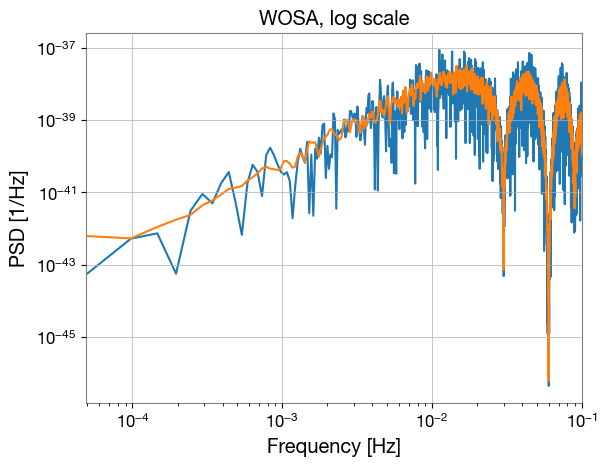

In [3]:
# 1) Find the PSD of the TDI time series
data, fs = readTdi(tdi_file_path)
nper = 4096

f, psd, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nper
) 

# 2) Generate a random noise realisation
timeNoise = time_noise_from_psd(psd, fs, nper)

# 3) Find the PSD of the time-domain-noise 
_, psd_noise, _ = wosa(
    x=timeNoise,
    fs=fs,
    nperseg= nper
)  

# Plot the Original PSD along with the noise: 
plt.figure()
plt.loglog(f, psd_noise)
plt.loglog(f, psd)
# plt.loglog(f_noise, psd / psd_noise) # to plot the ratio
plt.xlabel("Frequency [Hz]")
f_min = fs / nper
f_max = fs / 2.0
plt.xlim(f_min, f_max)
plt.ylabel("PSD [1/Hz]")
print(f)
print(psd_noise)
plt.title("WOSA, log scale")

Text(0.5, 1.0, 'WOSA, log scale')

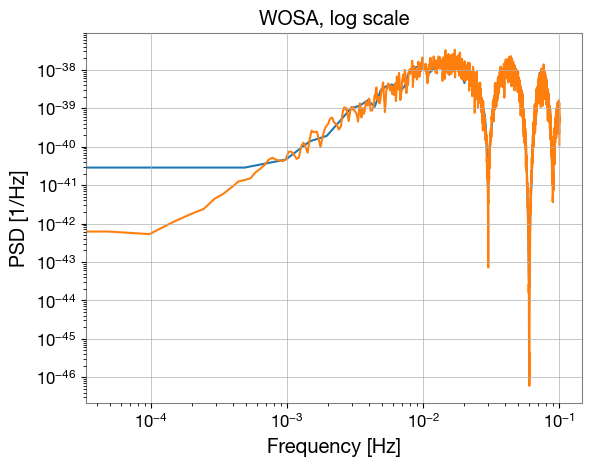

In [4]:
# 1) Find the PSD of the TDI time series
data, fs = readTdi(tdi_file_path)
nper = 4096

f, psd, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nper
) 

# 2) Generate a random noise realisation
timeNoise = time_noise_from_psd(psd, fs, nper)

# 3) Find the PSD of the time-domain-noise 
f_noise, psd_noise, _ = wosa(
    x=timeNoise,
    fs=fs,
    nperseg= nper // 10
)  

# Plot the Original PSD along with the noise: 
plt.figure()
plt.loglog(f_noise, psd_noise)
plt.loglog(f, psd)
# plt.loglog(f_noise, psd / psd_noise) # to plot the ratio
plt.xlabel("Frequency [Hz]")
# f_min = fs / nper
# f_max = fs / 2.0
#plt.xlim(f_min, f_max)
plt.ylabel("PSD [1/Hz]")
plt.title("WOSA, log scale")

In [5]:
print(f)
print(psd)
print(f_noise)
print(psd_noise)

In [6]:
print(f.shape)
print(psd.shape)
print(f_noise.shape)
print(psd_noise.shape)

Text(0.5, 1.0, 'WOSA, log scale')

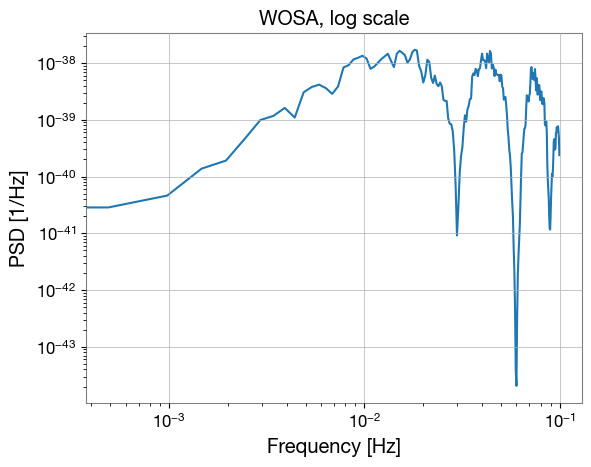

In [7]:
# Plot the Original PSD along with the noise: 
plt.figure()
plt.loglog(f_noise, psd_noise)
# plt.loglog(f, psd)
# plt.loglog(f_noise, psd / psd_noise) # to plot the ratio
plt.xlabel("Frequency [Hz]")
# f_min = fs / nper
# f_max = fs / 2.0
# plt.xlim(f_min, f_max)
plt.ylabel("PSD [1/Hz]")
plt.title("WOSA, log scale")

Text(0.5, 1.0, 'WOSA, log scale')

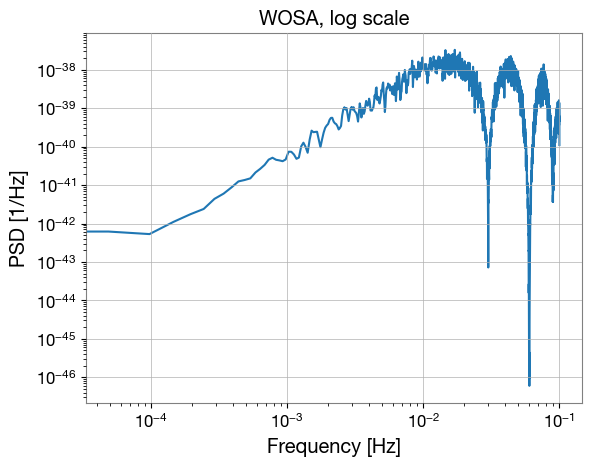

In [8]:
# Plot the Original PSD along with the noise: 
plt.figure()
# plt.loglog(f_noise, psd_noise)
plt.loglog(f, psd)
# plt.loglog(f_noise, psd / psd_noise) # to plot the ratio
plt.xlabel("Frequency [Hz]")
# f_min = fs / nper
# f_max = fs / 2.0
# plt.xlim(f_min, f_max)
plt.ylabel("PSD [1/Hz]")
plt.title("WOSA, log scale")